In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("tip.csv")
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
'''
Tip datasetinde 
1. Outlierleri tapin
2. Encoding tetbiq edin
3. Scaling tetbiq edin >> Z-score
4. Duplikatlar deyerlere baxin
5. Diskretlesdirin -- > En axirda
'''

q1 = np.quantile(df["total_bill"], 0.25)
q3 = np.quantile(df["total_bill"], 0.75)
iqr = q3 - q1 
minn = q1 - 1.5* iqr
maxx = q3 + 1.5 *iqr

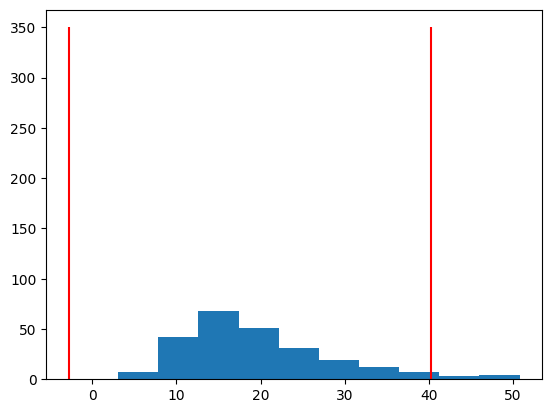

In [14]:
plt.hist(df["total_bill"])
plt.vlines(x = minn , ymin = 0 , ymax = 350, color="red")
plt.vlines(x = maxx , ymin = 0 , ymax = 350, color="red")

In [15]:
maxx

np.float64(40.29749999999999)

In [19]:
#2. Encoding tetbiq edin categoric rewemle 
df['day'].value_counts()



day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [20]:
pd.get_dummies(data= df, columns = ["day"],drop_first = True) 

,total_bill,tip,sex,smoker,time,size,day_Sat,day_Sun,day_Thur
0,16.99,1.01,Female,No,Dinner,2,False,True,False
1,10.34,1.66,Male,No,Dinner,3,False,True,False
2,21.01,3.50,Male,No,Dinner,3,False,True,False
3,23.68,3.31,Male,No,Dinner,2,False,True,False
4,24.59,3.61,Female,No,Dinner,4,False,True,False
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Dinner,3,True,False,False
240,27.18,2.00,Female,Yes,Dinner,2,True,False,False
241,22.67,2.00,Male,Yes,Dinner,2,True,False,False
242,17.82,1.75,Male,No,Dinner,2,True,False,False


In [26]:
#3. Scaling tetbiq edin >> Z-score

df["tip"] = df["tip"].apply(lambda x: (x - df["tip"].mean()) / df["tip"].std())
df["total_bill"] = df["total_bill"].apply(lambda x: (x - df["total_bill"].mean()) / df["total_bill"].std())
df.describe()



,total_bill,tip,size
count,2.440000e+02,2.440000e+02,244.000000
mean,-1.820038e-18,-1.456030e-17,2.569672
std,1.000000e+00,1.000000e+00,0.951100
min,-1.877687e+00,-1.444221e+00,1.000000
25%,-7.232245e-01,-7.214882e-01,2.000000
50%,-2.236408e-01,-7.102918e-02,2.000000
75%,4.876833e-01,4.077810e-01,3.000000
max,3.484905e+00,5.060370e+00,6.000000


In [34]:
#4. Duplikatlar deyerlere baxin
duplicates = df[df.duplicated()]
#df.duplicated().sum()
duplicates

,total_bill,tip,sex,smoker,day,time,size
202,-0.762259,-0.721488,Female,Yes,Thur,Lunch,2


(array([41., 79., 66., 27., 19.,  5.,  4.,  1.,  1.,  1.]),
 array([-1.44422054, -0.79376147, -0.14330241,  0.50715665,  1.15761572,
         1.80807478,  2.45853384,  3.1089929 ,  3.75945197,  4.40991103,
         5.06037009]),
 <BarContainer object of 10 artists>)

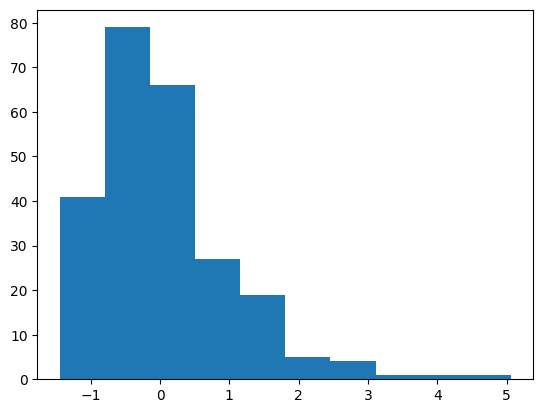

In [49]:
#5. Diskretlesdirin -- > En axirda
plt.hist(df['tip'])

In [53]:
minn=df['tip'].min()
maxx=df['tip'].max()
#minn

In [55]:


bins = [minn, 2, 3, maxx]  
labels = ['Low', 'Medium', 'High']

df['tip_binned'] = pd.cut(df['tip'], bins=bins, labels=labels, include_lowest=True)

df

,total_bill,tip,sex,smoker,day,time,size,tip_binned
0,16.99,1.01,Female,No,Sun,Dinner,2,Low
1,10.34,1.66,Male,No,Sun,Dinner,3,Low
2,21.01,3.50,Male,No,Sun,Dinner,3,High
3,23.68,3.31,Male,No,Sun,Dinner,2,High
4,24.59,3.61,Female,No,Sun,Dinner,4,High
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,High
240,27.18,2.00,Female,Yes,Sat,Dinner,2,Low
241,22.67,2.00,Male,Yes,Sat,Dinner,2,Low
242,17.82,1.75,Male,No,Sat,Dinner,2,Low
